# Workalong: Plotting geospatial data

This workalong shows how to use `rioxarray` to read a raster file (a GeoTIFF in this case) to add topography to our plot.  It also shows some tricks for getting good-looking topo plots.

## Installing `rioxarray`

1. Open a terminal
1. Load conda `module load conda`
1. Load your environment: `conda activate /N/slate/$USER/conda_envs/easg690`
1. Install rioxarray: `conda install -c conda-forge --solver libmamba rioxarray`

## Workalong

<iframe id="kaltura_player" src='https://cdnapisec.kaltura.com/p/1751071/embedPlaykitJs/uiconf_id/55382703?iframeembed=true&amp;entry_id=1_q1vvxfm1&amp;config%5Bprovider%5D=%7B%22widgetId%22%3A%221_7k45qu7q%22%7D&amp;config%5Bplayback%5D=%7B%22startTime%22%3A0%7D'  style="width: 528px;height: 297px;border: 0;" allowfullscreen webkitallowfullscreen mozAllowFullScreen allow="autoplay *; fullscreen *; encrypted-media *" sandbox="allow-downloads allow-forms allow-same-origin allow-scripts allow-top-navigation allow-pointer-lock allow-popups allow-modals allow-orientation-lock allow-popups-to-escape-sandbox allow-presentation allow-top-navigation-by-user-activation" title="EAS-G 690 - Lesson 13 part 2"></iframe>

*Use [this link](https://iu.mediaspace.kaltura.com/media/t/1_q1vvxfm1/388761952) if you have issues viewing the above embeded video.*


In [11]:
""" Import libraries """
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib as mpl
import rioxarray
import cartopy
import numpy as np
import cmocean
import cartopy.crs as ccrs

mpl.style.use('seaborn-v0_8-poster')

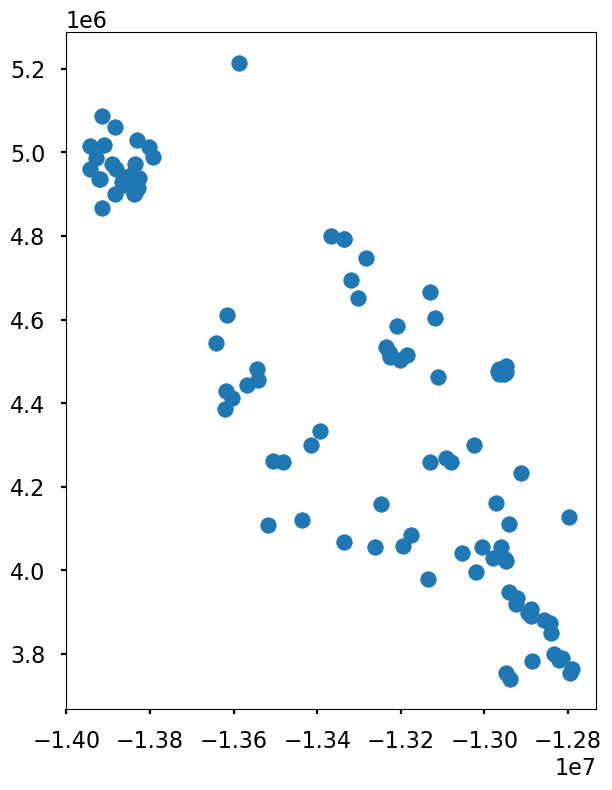

In [3]:
""" Load the earthquake data from the earlier exercise. """
data_file = "earthquake_gdf_ca_clipped.shp.zip"

# Load the data into a GeoDataFrame
ca_earthquakes_gdf = gpd.read_file(data_file)
ca_earthquakes_gdf.plot();

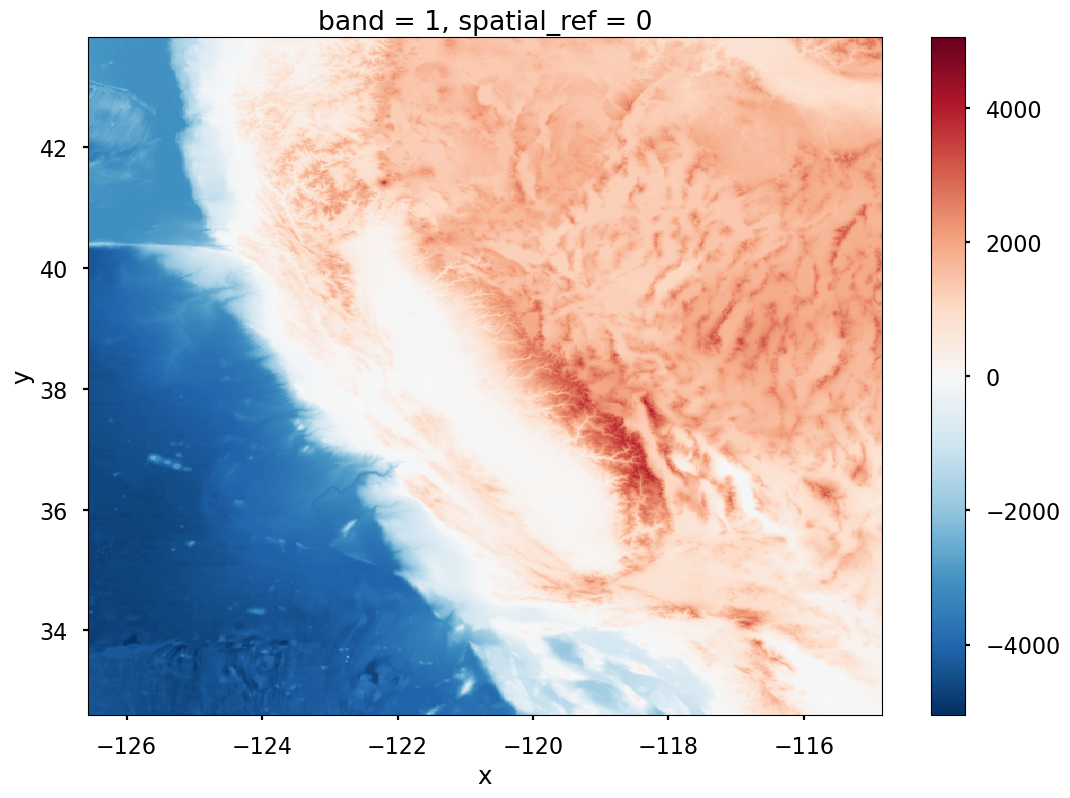

In [5]:
""" Load the topo / bathymetry data. """

# set the filepath
topo_bathy_path = "https://github.com/taobrienlbl/advanced_earth_science_data_analysis/raw/09188e9e6a0cf230f8473c0ae95d2e1b9079df3a/lessons/13_geospatial_intro/data/western_us_topo_bathy_subset.tiff"
topo_bathy_rxr = rioxarray.open_rasterio(topo_bathy_path)
topo_bathy_rxr.plot()


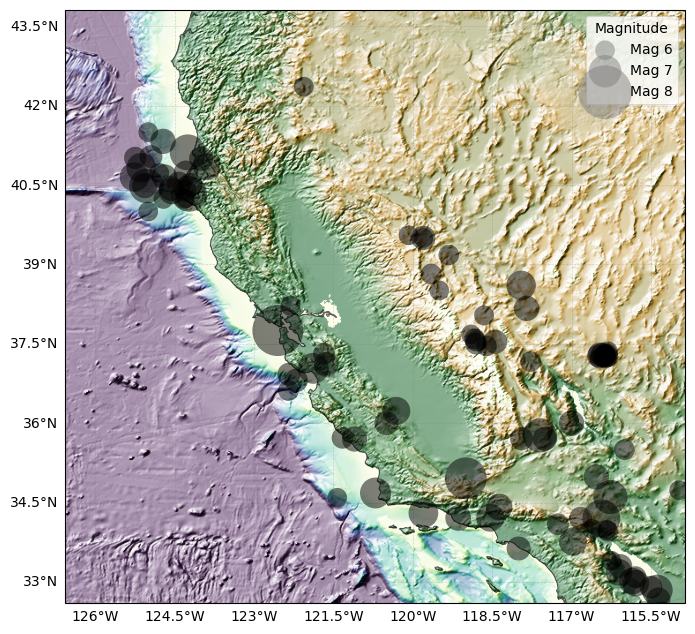

In [12]:
# Set the projection
projection = ccrs.PlateCarree()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection=projection))

# Get the projection as a PROJ string (or use EPSG code if preferred)
try:
    proj_target = projection.proj4_init
except:
    # Fallback if proj4_init is deprecated in your version
    proj_target = "EPSG:4326"

# **********************************************
# Create a hillshade of the topo/bathy data
# **********************************************
# Set the light source
ls = mpl.colors.LightSource(azdeg=315, altdeg=45)

# Reproject the topo/bathy data to match the plot projection
topo_bathy_rxr_proj = topo_bathy_rxr.rio.reproject(proj_target)

# Get the x and y grid spacing
dx = abs(topo_bathy_rxr_proj.x.diff('x').values[0])
dy = abs(topo_bathy_rxr_proj.y.diff('y').values[0])
rearth = 6.371e6 # Earth radius [m]

# Convert grid spacing to meters (approximation for Lat/Lon grids)
dx_meters = np.deg2rad(dx) * rearth * np.cos(np.deg2rad(topo_bathy_rxr.y.mean().values))
dy_meters = np.deg2rad(dy) * rearth

# Generate a blended hillshade
blend = ls.shade(
    topo_bathy_rxr_proj.squeeze().values, 
    dx=dx_meters, dy=dy_meters,
    vert_exag=10, 
    cmap=cmocean.cm.topo,
    blend_mode='hsv',
    vmin=-3000, vmax=3000
)

# Get the extent of the data 
left, bottom, right, top = topo_bathy_rxr_proj.rio.bounds()
extent_bounds = [left, right, bottom, top]

# Set the plot extent
ax.set_extent(extent_bounds, crs=projection)

# Plot the hillshade
ax.imshow(blend, extent=extent_bounds, transform=projection, origin='upper')

# **********************************************
# Plot the earthquake data
# **********************************************
# Convert the earthquake data to the correct CRS (PlateCarree/WGS84)
ca_earthquakes_gdf_proj = ca_earthquakes_gdf.to_crs(epsg=4326)

# Calculate marker sizes (Area)
# Adjusted the divisor since scatter uses area (pixels^2), not diameter
sizes_data = np.exp(ca_earthquakes_gdf_proj.mag) / 2

# Plot using scatter (better control over transform and size than gdf.plot)
sc = ax.scatter(
    ca_earthquakes_gdf_proj.geometry.x,
    ca_earthquakes_gdf_proj.geometry.y,
    s=sizes_data,           # s = area
    c="black",
    alpha=0.5,
    zorder=10,
    transform=projection,   # Crucial for proper alignment in Cartopy
    edgecolors='none'       # Removes the border for a cleaner look
)

# **********************************************
# Create a legend 
# **********************************************
sizes = [6, 7, 8]
# Use the same math as above to ensure legend sizes match plot sizes
exp_sizes = np.exp(sizes) / 2
labels = [f"Mag {s}" for s in sizes]

# Generate dummy handles for the legend
handles = [plt.scatter([], [], s=s, color="gray", alpha=0.5, edgecolors='none') for s in exp_sizes]

# Create the legend
leg = ax.legend(handles, labels, title="Magnitude", loc="upper right", fontsize=10, frameon=True)

# **********************************************
# Geographic features
# **********************************************
# Gridlines
gl = ax.gridlines(draw_labels=True, color="gray", alpha=0.3, linestyle="--", linewidth=0.5)
gl.top_labels = False 
gl.right_labels = False

# Coastlines
ax.coastlines(resolution="10m", color="black", linewidth=0.8, alpha=0.6)

plt.show()